In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
video_path = "data/cctv.mp4"

cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print("Error: Cannot open video")

In [3]:
ret, frame = cap.read()

if not ret:
    print("Error reading frame")
else:
    print("Frame shape:", frame.shape)

Frame shape: (720, 1280, 3)


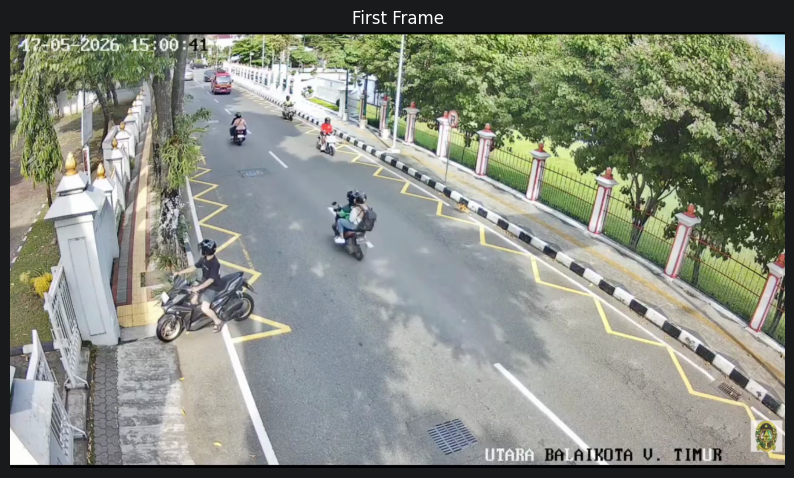

In [4]:
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 6))
plt.imshow(frame_rgb)
plt.title("First Frame")
plt.axis("off")
plt.show()

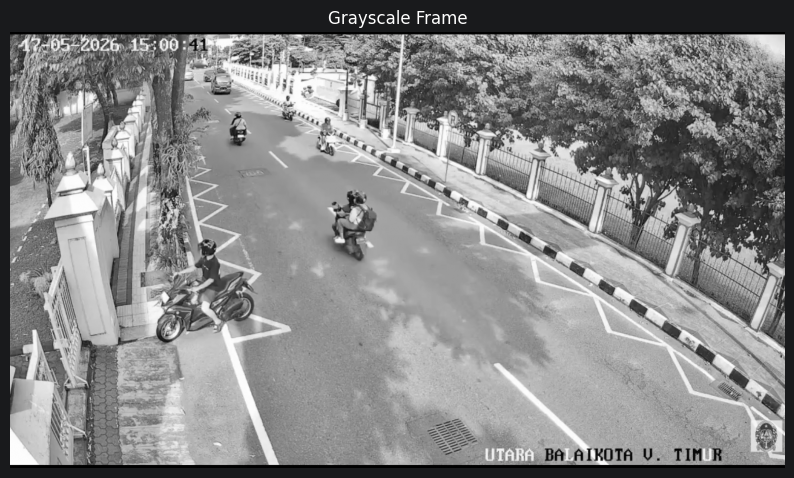

In [5]:
gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(10, 6))
plt.imshow(gray_frame, cmap='gray')
plt.title("Grayscale Frame")
plt.axis("off")
plt.show()

In [6]:
bbox = (331, 65, 37, 38)
print("Bounding Box:", bbox)

Bounding Box: (331, 65, 37, 38)


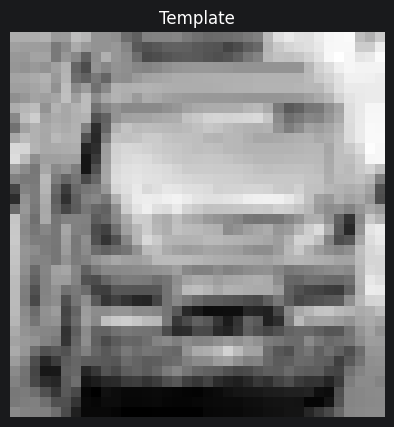

In [7]:
x, y, w, h = bbox

template = gray_frame[y:y+h, x:x+w]

plt.figure(figsize=(5, 5))
plt.imshow(template, cmap='gray')
plt.title("Template")
plt.axis("off")
plt.show()

### Template Matching

In [8]:
ret, next_frame = cap.read()

if not ret:
    print("Failed to read next frame")

next_gray = cv2.cvtColor(next_frame, cv2.COLOR_BGR2GRAY)

In [9]:
search_margin = 30

x_min = max(0, x - search_margin)
y_min = max(0, y - search_margin)

x_max = min(next_gray.shape[1] - w, x + search_margin)
y_max = min(next_gray.shape[0] - h, y + search_margin)

best_ssd = float('inf')
best_x = x
best_y = y

for j in range(y_min, y_max):
    for i in range(x_min, x_max):

        # Extract candidate patch
        patch = next_gray[j:j+h, i:i+w]

        # Compute SSD manually
        difference = template.astype(np.float32) - patch.astype(np.float32)

        ssd = np.sum(difference ** 2)

        # Update best match
        if ssd < best_ssd:
            best_ssd = ssd
            best_x = i
            best_y = j

result_frame = next_frame.copy()

cv2.rectangle(
    result_frame,
    (best_x, best_y),
    (best_x + w, best_y + h),
    (0, 255, 0),
    2
)

array([[[5, 1, 1],
        [5, 1, 1],
        [5, 1, 1],
        ...,
        [1, 3, 0],
        [1, 3, 0],
        [1, 3, 0]],

       [[5, 1, 1],
        [5, 1, 1],
        [5, 1, 1],
        ...,
        [1, 3, 0],
        [1, 3, 0],
        [1, 3, 0]],

       [[0, 2, 1],
        [0, 2, 1],
        [0, 2, 1],
        ...,
        [0, 3, 0],
        [0, 3, 0],
        [0, 3, 0]],

       ...,

       [[0, 1, 0],
        [0, 1, 0],
        [0, 1, 0],
        ...,
        [0, 0, 2],
        [0, 0, 2],
        [0, 0, 2]],

       [[0, 1, 0],
        [0, 1, 0],
        [0, 1, 0],
        ...,
        [3, 0, 2],
        [3, 0, 2],
        [3, 0, 2]],

       [[0, 1, 0],
        [0, 1, 0],
        [0, 1, 0],
        ...,
        [3, 0, 2],
        [3, 0, 2],
        [3, 0, 2]]], shape=(720, 1280, 3), dtype=uint8)

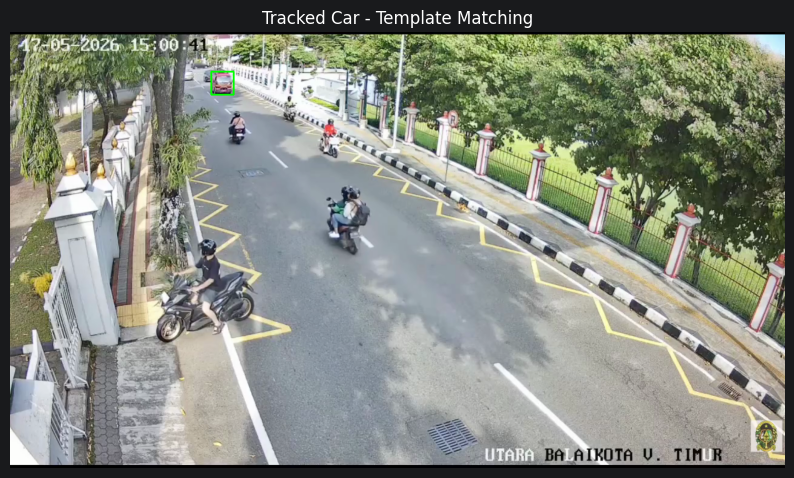

In [10]:
result_rgb = cv2.cvtColor(result_frame, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 6))
plt.imshow(result_rgb)
plt.title("Tracked Car - Template Matching")
plt.axis("off")
plt.show()

In [11]:
cap.release()
cap = cv2.VideoCapture(video_path)

ret, frame = cap.read()
if not ret:
    print("Failed to read video")

# Convert to grayscale
gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

In [12]:
# Reuse bounding box
x, y, w, h = bbox

# Recreate template
template = gray_frame[y:y+h, x:x+w]

frame_height, frame_width = frame.shape[:2]

fourcc = cv2.VideoWriter_fourcc(*'mp4v')

out = cv2.VideoWriter(
    'outputs/template_tracking.mp4',
    fourcc,
    30,
    (frame_width, frame_height)
)

In [13]:
search_margin = 30

while True:

    ret, frame = cap.read()

    if not ret:
        break

    # Convert to grayscale
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Define search window
    x_min = max(0, x - search_margin)
    y_min = max(0, y - search_margin)

    x_max = min(gray.shape[1] - w, x + search_margin)
    y_max = min(gray.shape[0] - h, y + search_margin)

    # Initialize best match
    best_ssd = float('inf')
    best_x = x
    best_y = y

    # Sliding window search
    for j in range(y_min, y_max):
        for i in range(x_min, x_max):

            patch = gray[j:j+h, i:i+w]

            difference = template.astype(np.float32) - patch.astype(np.float32)

            ssd = np.sum(difference ** 2)

            if ssd < best_ssd:
                best_ssd = ssd
                best_x = i
                best_y = j

    # Update bbox position
    x = best_x
    y = best_y

    # Draw tracking box
    cv2.rectangle(
        frame,
        (x, y),
        (x + w, y + h),
        (0, 255, 0),
        2
    )

    # Save frame
    out.write(frame)

    # Display
    cv2.imshow("Template Tracking", frame)

    # Press Q to stop
    if cv2.waitKey(30) & 0xFF == ord('q'):
        break

cap.release()
out.release()
cv2.destroyAllWindows()

### Optical Flow

In [14]:
cap.release()

cap = cv2.VideoCapture(video_path)

ret, frame1 = cap.read()
ret, frame2 = cap.read()

frame1_gray = cv2.cvtColor(frame1, cv2.COLOR_BGR2GRAY)
frame2_gray = cv2.cvtColor(frame2, cv2.COLOR_BGR2GRAY)

In [15]:
frame1_gray = frame1_gray.astype(np.float32)
frame2_gray = frame2_gray.astype(np.float32)

Ix = np.zeros_like(frame1_gray)
Iy = np.zeros_like(frame1_gray)

for y in range(1, frame1_gray.shape[0] - 1):
    for x in range(1, frame1_gray.shape[1] - 1):

        Ix[y, x] = (
            frame1_gray[y, x + 1] -
            frame1_gray[y, x - 1]
        ) / 2.0

for y in range(1, frame1_gray.shape[0] - 1):
    for x in range(1, frame1_gray.shape[1] - 1):

        Iy[y, x] = (
            frame1_gray[y + 1, x] -
            frame1_gray[y - 1, x]
        ) / 2.0

It = frame2_gray - frame1_gray

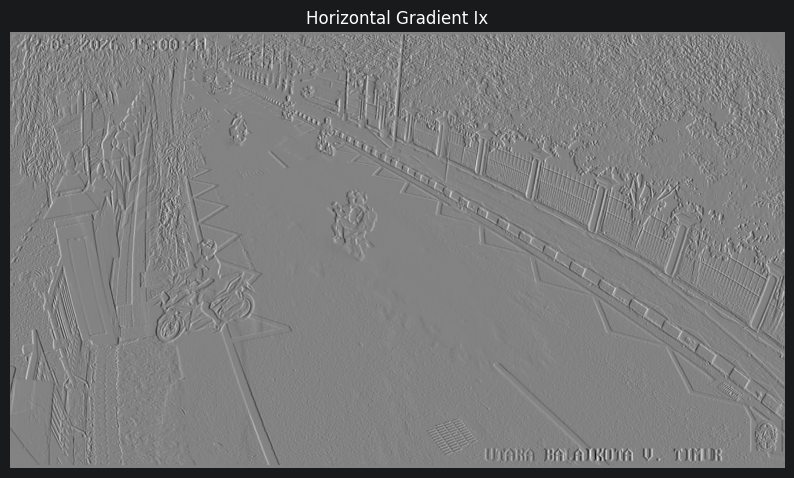

In [16]:
plt.figure(figsize=(10, 6))
plt.imshow(Ix, cmap='gray')
plt.title("Horizontal Gradient Ix")
plt.axis("off")
plt.show()

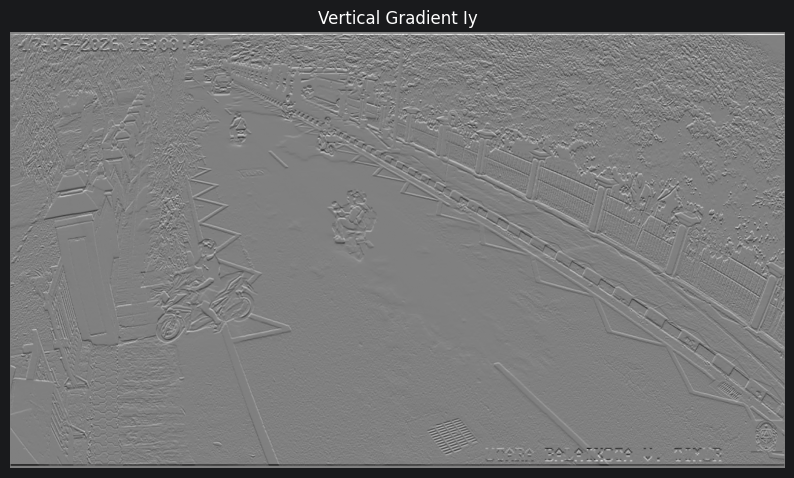

In [17]:
plt.figure(figsize=(10, 6))
plt.imshow(Iy, cmap='gray')
plt.title("Vertical Gradient Iy")
plt.axis("off")
plt.show()

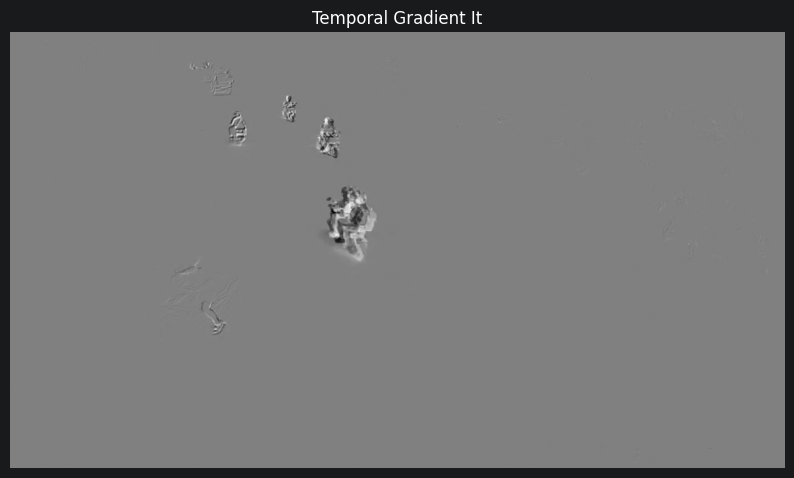

In [18]:
plt.figure(figsize=(10, 6))
plt.imshow(It, cmap='gray')
plt.title("Temporal Gradient It")
plt.axis("off")
plt.show()

In [19]:
point_x = 500
point_y = 300

window_size = 5
half_window = window_size // 2

In [20]:
A = []
b = []

y_start = max(0, point_y - half_window)
y_end   = min(Ix.shape[0] - 1, point_y + half_window)

x_start = max(0, point_x - half_window)
x_end   = min(Ix.shape[1] - 1, point_x + half_window)

for j in range(y_start, y_end + 1):
    for i in range(x_start, x_end + 1):

        ix = Ix[j, i]
        iy = Iy[j, i]
        it = It[j, i]

        A.append([ix, iy])
        b.append([-it])

A = np.array(A, dtype=np.float32)
b = np.array(b, dtype=np.float32)

print("A shape:", A.shape)
print("b shape:", b.shape)

A shape: (25, 2)
b shape: (25, 1)


In [21]:
A = np.array(A)
b = np.array(b)

ATA = A.T @ A
ATb = A.T @ b

flow = np.linalg.inv(ATA) @ ATb

u = flow[0, 0]
v = flow[1, 0]

In [22]:
print("Optical Flow Vector:")
print("u =", u)
print("v =", v)

Optical Flow Vector:
u = 0.0
v = 0.0


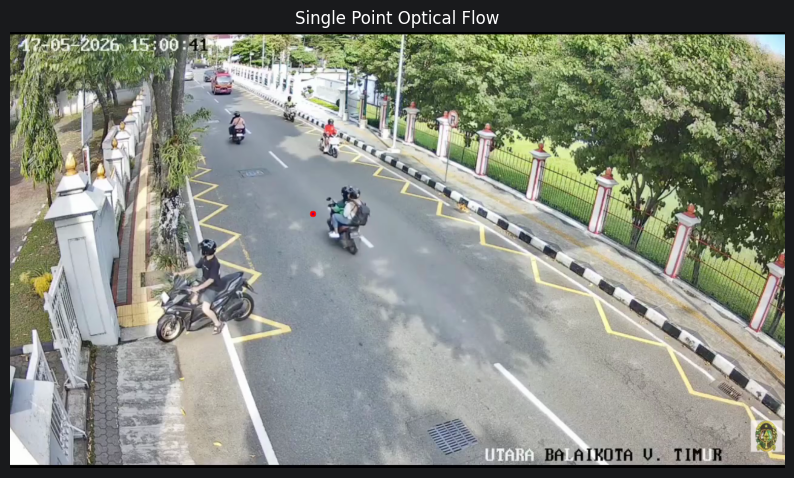

In [23]:
flow = np.linalg.inv(ATA) @ ATb
flow = np.linalg.pinv(ATA) @ ATb

result = frame2.copy()

new_x = int(point_x + u)
new_y = int(point_y + v)

# Original point
cv2.circle(result, (point_x, point_y), 5, (0, 255, 0), -1)

# New point
cv2.circle(result, (new_x, new_y), 5, (0, 0, 255), -1)

# Motion line
cv2.line(
    result,
    (point_x, point_y),
    (new_x, new_y),
    (255, 0, 0),
    2
)

result_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,6))
plt.imshow(result_rgb)
plt.title("Single Point Optical Flow")
plt.axis("off")
plt.show()

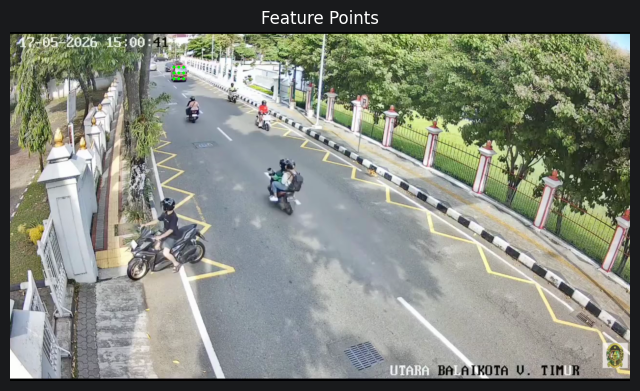

In [24]:
feature_points = [
    (338, 72),
    (348, 72),
    (358, 72),

    (338, 84),
    (348, 84),
    (358, 84),

    (338, 96),
    (348, 96),
    (358, 96),
]

debug_frame = frame1.copy()

for (px, py) in feature_points:
    cv2.circle(debug_frame, (px, py), 3, (0, 255, 0), -1)

debug_rgb = cv2.cvtColor(debug_frame, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,6))
plt.imshow(debug_rgb)
plt.title("Feature Points")
plt.axis("off")
plt.show()

In [25]:
new_points = []
window_size = 5
half_window = window_size // 2

for (point_x, point_y) in feature_points:

    A = []
    b = []

    # Safe boundaries
    y_start = max(0, point_y - half_window)
    y_end   = min(Ix.shape[0] - 1, point_y + half_window)

    x_start = max(0, point_x - half_window)
    x_end   = min(Ix.shape[1] - 1, point_x + half_window)

    # Build system
    for j in range(y_start, y_end + 1):
        for i in range(x_start, x_end + 1):

            ix = Ix[j, i]
            iy = Iy[j, i]
            it = It[j, i]

            A.append([ix, iy])
            b.append([-it])

    A = np.array(A, dtype=np.float32)
    b = np.array(b, dtype=np.float32)

    # Solve flow
    ATA = A.T @ A
    ATb = A.T @ b

    flow = np.linalg.pinv(ATA) @ ATb

    u = flow[0, 0]
    v = flow[1, 0]

    # New position
    new_x = int(point_x + u)
    new_y = int(point_y + v)

    new_points.append((new_x, new_y))

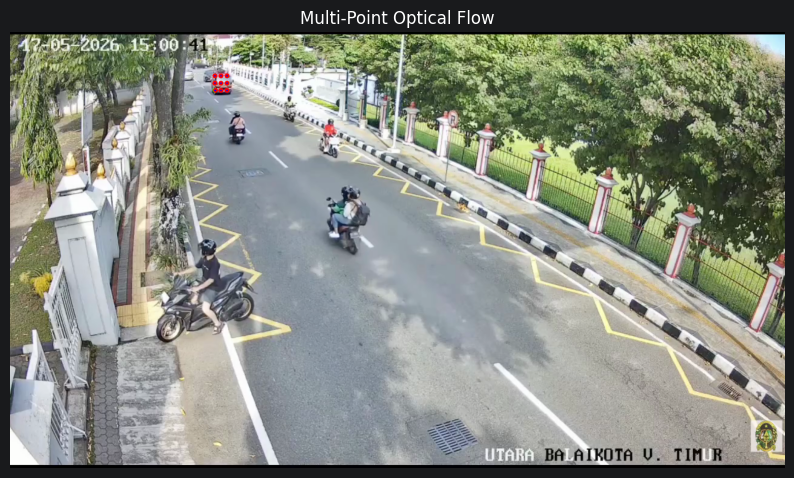

In [26]:
result = frame2.copy()

for (old_pt, new_pt) in zip(feature_points, new_points):

    old_x, old_y = old_pt
    new_x, new_y = new_pt

    # Original point
    cv2.circle(result, (old_x, old_y), 4, (0, 255, 0), -1)

    # New point
    cv2.circle(result, (new_x, new_y), 4, (0, 0, 255), -1)

    # Motion vector
    cv2.line(
        result,
        (old_x, old_y),
        (new_x, new_y),
        (255, 0, 0),
        2
    )

result_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,6))
plt.imshow(result_rgb)
plt.title("Multi-Point Optical Flow")
plt.axis("off")
plt.show()

In [27]:
dx_list = []
dy_list = []

for (old_pt, new_pt) in zip(feature_points, new_points):

    old_x, old_y = old_pt
    new_x, new_y = new_pt

    dx_list.append(new_x - old_x)
    dy_list.append(new_y - old_y)

mean_dx = int(np.mean(dx_list))
mean_dy = int(np.mean(dy_list))

print("Average Motion:")
print("dx =", mean_dx)
print("dy =", mean_dy)

Average Motion:
dx = 0
dy = 0


In [28]:
cap.release()

cap = cv2.VideoCapture(video_path)

ret, frame1 = cap.read()

frame1_gray = cv2.cvtColor(frame1, cv2.COLOR_BGR2GRAY)
frame1_gray = frame1_gray.astype(np.float32)

frame_height, frame_width = frame1.shape[:2]

fourcc = cv2.VideoWriter_fourcc(*'mp4v')

out = cv2.VideoWriter(
    'outputs/optical_flow_tracking.mp4',
    fourcc,
    30,
    (frame_width, frame_height)
)

In [29]:
window_size = 5
half_window = window_size // 2

while True:

    ret, frame2 = cap.read()

    if not ret:
        break

    frame2_gray = cv2.cvtColor(frame2, cv2.COLOR_BGR2GRAY)
    frame2_gray = frame2_gray.astype(np.float32)

    # Compute gradients
    Ix = np.zeros_like(frame1_gray)
    Iy = np.zeros_like(frame1_gray)

    for yy in range(1, frame1_gray.shape[0] - 1):
        for xx in range(1, frame1_gray.shape[1] - 1):

            Ix[yy, xx] = (
                frame1_gray[yy, xx + 1] -
                frame1_gray[yy, xx - 1]
            ) / 2.0

            Iy[yy, xx] = (
                frame1_gray[yy + 1, xx] -
                frame1_gray[yy - 1, xx]
            ) / 2.0

    It = frame2_gray - frame1_gray

    new_points = []

    dx_list = []
    dy_list = []

    # Track each feature point
    for (point_x, point_y) in feature_points:

        A = []
        b = []

        y_start = int(max(0, point_y - half_window))
        y_end   = int(min(Ix.shape[0] - 1, point_y + half_window))

        x_start = int(max(0, point_x - half_window))
        x_end   = int(min(Ix.shape[1] - 1, point_x + half_window))

        for j in range(y_start, y_end + 1):
            for i in range(x_start, x_end + 1):

                ix = Ix[j, i]
                iy = Iy[j, i]
                it = It[j, i]

                A.append([ix, iy])
                b.append([-it])

        A = np.array(A, dtype=np.float32)
        b = np.array(b, dtype=np.float32)

        ATA = A.T @ A
        ATb = A.T @ b

        flow = np.linalg.pinv(ATA) @ ATb

        u = flow[0, 0]
        v = flow[1, 0]

        new_x = point_x + u
        new_y = point_y + v

        dx_list.append(u)
        dy_list.append(v)

        new_points.append((new_x, new_y))

    # Average motion
    mean_dx = np.mean(dx_list)
    mean_dy = np.mean(dy_list)

    # Update bounding box
    x += int(mean_dx)
    y += int(mean_dy)

    # Draw bbox
    cv2.rectangle(
        frame2,
        (x, y),
        (x + w, y + h),
        (0, 255, 0),
        2
    )

    # Draw feature points
    for (px, py) in new_points:

        cv2.circle(
            frame2,
            (int(px), int(py)),
            3,
            (0, 0, 255),
            -1
        )

    # Save frame
    out.write(frame2)

    # Display
    cv2.imshow("Optical Flow Tracking", frame2)

    # Update for next iteration
    feature_points = new_points
    frame1_gray = frame2_gray.copy()

    # Quit key
    if cv2.waitKey(30) & 0xFF == ord('q'):
        break